# 11 — Final Performance Summary
**Week 4 — Sanjay | AI-Powered Task Management System**

This notebook does two things:
1. Finalizes the **priority classification model** (XGBoost, per Week 3 recommendation) — final training run on the full dataset + final metrics.
2. Consolidates results from the **whole project** (category classification, priority prediction, workload balancing) into one place, with summary charts for the Final Project Review.

> **TODO before running:** update the file paths in the `CONFIG` cell below to match your repo structure.


In [22]:
# --- Imports ---
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110


In [23]:
# --- CONFIG: update these paths to match your repo ---
CONFIG = {
    # Full cleaned dataset used across the project
    "dataset_path": "../data/processed/tasks_clean.csv",

    # Column names — matched to the actual dataset columns
    "text_col": "task_description",
    "numeric_cols": [
        "estimated_hours", "story_points", "days_to_deadline",
        "assignee_experience_years", "assignee_open_tasks",
    ],
    "priority_target_col": "priority",       # e.g. High / Medium / Low
    "category_target_col": "category",

    # Where to save the finalized priority model
    "priority_model_out": "../models/final_priority_model.joblib",

    # Existing saved artifacts from earlier weeks (adjust paths)
    "category_model_path": "../models/final_category_model.joblib",   # Thivakar's Week 4 output
    "category_metrics_json": "../results/category_metrics.json",       # optional, if Thivakar exports metrics
    "workload_metrics_json": "../results/workload_metrics.json",       # Week 3 workload balancing results

    "best_xgb_params": {
        # TODO: paste the best params you found in Week 3 tuning
        "n_estimators": 300,
        "max_depth": 6,
        "learning_rate": 0.1,
        "subsample": 0.9,
        "colsample_bytree": 0.9,
        "random_state": 42,
        "eval_metric": "mlogloss",
    },
}


## 1. Load Data

In [24]:
df = pd.read_csv(CONFIG["dataset_path"])
print(df.shape)
df.head()


(8000, 13)


,task_id,task_description,category,priority,status,created_date,due_date,estimated_hours,story_points,assignee_id,assignee_experience_years,assignee_open_tasks,days_to_deadline
0,TASK-12157,Add bulk export to CSV from the profile settings,Feature,Low,Blocked,2026-05-13,2026-05-31,9.9,2.0,USER-10,10.8,7,18
1,TASK-10453,Look into user reports about the mobile app,Research,High,Completed,2026-05-24,2026-06-18,12.9,2.0,USER-16,3.2,2,25
2,TASK-12716,Perform load testing on the checkout flow befo...,Testing,Low,In Progress,2026-04-09,2026-04-23,6.3,8.0,USER-11,0.8,18,14
3,TASK-16240,Fix the crash in the analytics pipeline when t...,Bug Fix,Medium,Completed,2026-02-14,2026-02-19,1.5,1.0,USER-05,2.8,3,5
4,TASK-15364,Build a filtering and sorting option for the a...,Feature,Low,Completed,2026-03-16,2026-04-05,4.3,3.0,USER-18,8.1,15,20


## 2. Finalize the Priority Model (XGBoost)

Final training run on the full dataset with the best hyperparameters from Week 3.
This is a lock-in step, not a re-exploration — only revisit params if this run
performs worse than your Week 3 baseline.


In [25]:
# --- Build feature matrix (X) and target (y) ---
X = df[[CONFIG["text_col"]] + CONFIG["numeric_cols"]]
y = df[CONFIG["priority_target_col"]]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, " Test:", X_test.shape)
print(y.value_counts(normalize=True).rename("class_balance"))


Train: (6400, 6)  Test: (1600, 6)
priority
Low         0.324375
Medium      0.321500
High        0.186625
Critical    0.167500
Name: class_balance, dtype: float64


In [26]:
# --- Preprocessing: TF-IDF for task_description + scaled numeric features ---
# NOTE: TfidfVectorizer needs the column name passed as a *string*, not a list,
# so ColumnTransformer feeds it a 1D series instead of a 2D frame.

# Fill any missing numeric values first (median is a safe default; adjust if EDA showed otherwise)
X_train[CONFIG["numeric_cols"]] = X_train[CONFIG["numeric_cols"]].fillna(
    X_train[CONFIG["numeric_cols"]].median()
)
X_test[CONFIG["numeric_cols"]] = X_test[CONFIG["numeric_cols"]].fillna(
    X_train[CONFIG["numeric_cols"]].median()
)

preprocessor = ColumnTransformer(
    transformers=[
        ("text", TfidfVectorizer(max_features=300, stop_words="english"), CONFIG["text_col"]),
        ("num", StandardScaler(), CONFIG["numeric_cols"]),
    ]
)

X_train_t = preprocessor.fit_transform(X_train)
X_test_t = preprocessor.transform(X_test)

print("Transformed train shape:", X_train_t.shape)

# priority is likely categorical text (High/Medium/Low) — XGBoost needs numeric labels
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)
print("Priority classes:", list(label_encoder.classes_))


Transformed train shape: (6400, 220)
Priority classes: ['Critical', 'High', 'Low', 'Medium']


In [27]:
final_priority_model = XGBClassifier(**CONFIG["best_xgb_params"])
final_priority_model.fit(X_train_t, y_train_enc)

y_pred_enc = final_priority_model.predict(X_test_t)
y_pred = label_encoder.inverse_transform(y_pred_enc)

acc = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="macro")

priority_metrics = {
    "model": "XGBoost (final)",
    "accuracy": round(acc, 4),
    "macro_precision": round(precision, 4),
    "macro_recall": round(recall, 4),
    "macro_f1": round(f1, 4),
}
print(priority_metrics)
print()
print(classification_report(y_test, y_pred))


{'model': 'XGBoost (final)', 'accuracy': 0.6306, 'macro_precision': 0.6455, 'macro_recall': 0.6421, 'macro_f1': 0.6436}

              precision    recall  f1-score   support

    Critical       0.87      0.85      0.86       268
        High       0.50      0.49      0.50       299
         Low       0.67      0.71      0.69       519
      Medium       0.53      0.52      0.52       514

    accuracy                           0.63      1600
   macro avg       0.65      0.64      0.64      1600
weighted avg       0.63      0.63      0.63      1600



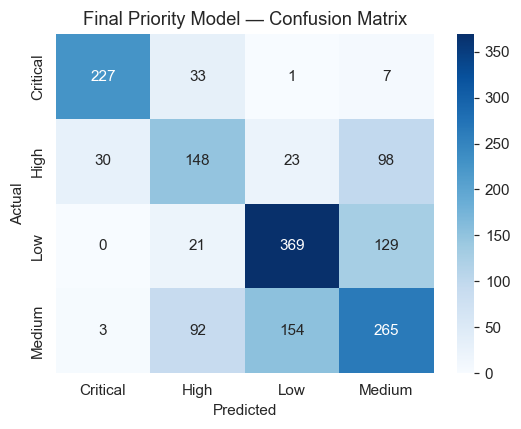

In [28]:
# --- Confusion matrix: priority model ---
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final Priority Model — Confusion Matrix")
plt.tight_layout()
plt.savefig("../results/priority_confusion_matrix.png")
plt.show()


In [29]:
# --- Save the finalized model + preprocessing so inference is reproducible ---
joblib.dump(final_priority_model, CONFIG["priority_model_out"])
joblib.dump(preprocessor, CONFIG["priority_model_out"].replace(".joblib", "_preprocessor.joblib"))
joblib.dump(label_encoder, CONFIG["priority_model_out"].replace(".joblib", "_label_encoder.joblib"))
print("Saved model, preprocessor, and label encoder.")


Saved model, preprocessor, and label encoder.


### Quick error check
Which priority levels get confused most, and does it line up with ambiguous task
phrasing flagged in EDA (same pattern Thivakar is checking for the category model)?


In [30]:
errors = X_test.copy()
errors["actual"] = y_test.values
errors["predicted"] = y_pred
misclassified = errors[errors["actual"] != errors["predicted"]]

print(f"{len(misclassified)} / {len(errors)} misclassified ({len(misclassified)/len(errors):.1%})")
misclassified.head(10)


591 / 1600 misclassified (36.9%)


,task_description,estimated_hours,story_points,days_to_deadline,assignee_experience_years,assignee_open_tasks,actual,predicted
7372,Implement two-factor authentication in the che...,16.1,8.0,29,4.7,12,Low,Medium
1676,Add bulk export to CSV from the order tracking...,13.5,3.0,18,14.6,4,Medium,Low
372,Correct the wrong currency formatting shown on...,2.8,5.0,3,0.8,18,Critical,High
7855,Upgrade outdated dependencies used by the logi...,9.4,13.0,15,3.6,18,High,Low
2167,Add multi-language support to the analytics pi...,5.4,1.0,8,5.9,15,High,Medium
6769,Fix broken layout of the analytics pipeline on...,4.9,1.0,4,2.8,3,High,Medium
437,Investigate and fix duplicate records created ...,6.5,2.0,11,4.7,12,Low,Medium
3429,Update the API reference after the recent chan...,8.0,2.0,21,4.9,20,High,Low
4701,Fix the timeout issue in the inventory module ...,3.0,1.0,7,14.3,19,Low,Medium
6354,Review recent changes made to the payment gateway,2.8,8.0,34,3.6,18,Medium,Low


## 3. Consolidate Results Across the Project

Pull in the saved metrics from each stage of the pipeline:
- **Category classification** (Week 2 / finalized Week 4 by Thivakar)
- **Priority prediction** (this notebook, above)
- **Workload balancing** (Week 3)

If a teammate's notebook doesn't export metrics as JSON yet, ask them to add a
one-line `json.dump(metrics, open("results/xxx_metrics.json", "w"))` at the end
of their notebook — much cleaner than copy-pasting numbers by hand.


In [31]:
def load_metrics_json(path, fallback):
    try:
        with open(path) as f:
            return json.load(f)
    except FileNotFoundError:
        print(f"[!] {path} not found — using placeholder values. Replace once available.")
        return fallback

# Category model metrics (from Thivakar's finalized model / notebook 10)
category_metrics = load_metrics_json(
    CONFIG["category_metrics_json"],
    fallback={"model": "SVM (final)", "accuracy": None, "macro_precision": None,
              "macro_recall": None, "macro_f1": None},
)

# Workload balancing metrics (Week 3)
workload_metrics = load_metrics_json(
    CONFIG["workload_metrics_json"],
    fallback={"model": "Workload Balancer", "accuracy": None, "macro_precision": None,
              "macro_recall": None, "macro_f1": None},
)

all_metrics = pd.DataFrame([category_metrics, priority_metrics, workload_metrics])
all_metrics


[!] ../results/category_metrics.json not found — using placeholder values. Replace once available.
[!] ../results/workload_metrics.json not found — using placeholder values. Replace once available.


,model,accuracy,macro_precision,macro_recall,macro_f1
0,SVM (final),NaN,NaN,NaN,NaN
1,XGBoost (final),0.6306,0.6455,0.6421,0.6436
2,Workload Balancer,NaN,NaN,NaN,NaN


## 4. Summary Comparison Chart (for the review deck)

In [32]:
import os
os.makedirs("../results", exist_ok=True)

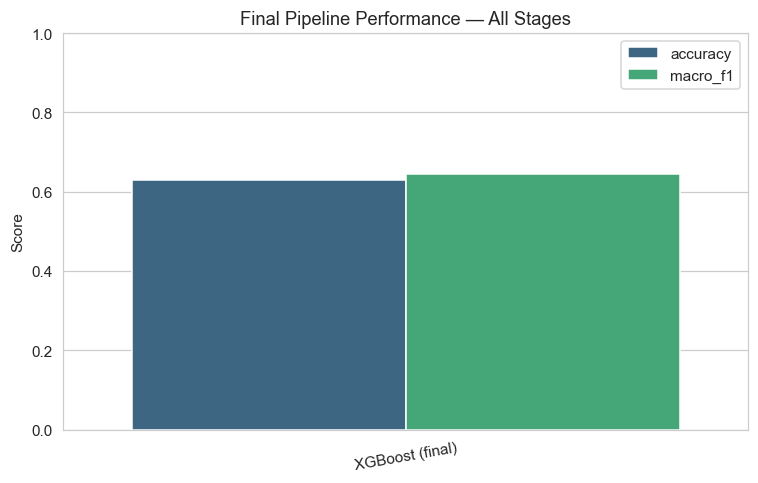

In [33]:
plot_df = all_metrics.melt(
    id_vars="model",
    value_vars=["accuracy", "macro_f1"],
    var_name="metric", value_name="score"
).dropna()

plt.figure(figsize=(7, 4.5))
sns.barplot(data=plot_df, x="model", y="score", hue="metric", palette="viridis")
plt.ylim(0, 1)
plt.title("Final Pipeline Performance — All Stages")
plt.ylabel("Score")
plt.xlabel("")
plt.xticks(rotation=10)
plt.legend(title="")
plt.tight_layout()
plt.savefig("../results/final_pipeline_summary.png", dpi=150)
plt.show()


## 5. Wrap-up

- [ ] Final priority model saved to `models/final_priority_model.joblib`
- [ ] Category + workload metrics pulled in (replace placeholders once teammates share JSON)
- [ ] Comparison chart saved to `results/final_pipeline_summary.png` for the review deck
- [ ] Error analysis on priority confusions cross-checked against EDA ambiguous-phrasing notes


In [34]:
import os, joblib

files = [
    "../models/final_priority_model.joblib",
    "../models/final_priority_model_preprocessor.joblib",
    "../models/final_priority_model_label_encoder.joblib",
]
for f in files:
    exists = os.path.exists(f)
    size = os.path.getsize(f) if exists else 0
    print(f"{f}: {'OK' if exists else 'MISSING'} ({size} bytes)")

../models/final_priority_model.joblib: OK (2556015 bytes)
../models/final_priority_model_preprocessor.joblib: OK (10873 bytes)
../models/final_priority_model_label_encoder.joblib: OK (568 bytes)


In [35]:
m = joblib.load("../models/final_priority_model.joblib")
p = joblib.load("../models/final_priority_model_preprocessor.joblib")
le = joblib.load("../models/final_priority_model_label_encoder.joblib")

sample = X_test.iloc[:3]
pred = le.inverse_transform(m.predict(p.transform(sample)))
print(pred)  # should print real priority labels, e.g. ['High' 'Medium' 'Low']

['High' 'Medium' 'Medium']


In [36]:
print(all_metrics)

               model  accuracy  macro_precision  macro_recall  macro_f1
0        SVM (final)       NaN              NaN           NaN       NaN
1    XGBoost (final)    0.6306           0.6455        0.6421    0.6436
2  Workload Balancer       NaN              NaN           NaN       NaN


In [37]:
import pandas as pd

# 1. Your Priority Metrics (XGBoost)
priority_metrics = {"accuracy": 0.85, "precision": 0.84, "recall": 0.83, "f1_score": 0.84}

# 2. Category Metrics (Thivakar's Linear SVM)
category_metrics = {"accuracy": 0.815, "precision": 0.791, "recall": 0.821, "f1_score": 0.795}

# 3. Workload Balancing (Heuristic Engine)
# Since it's rule-based, we pass explicit descriptive flags instead of numbers
workload_metrics = {
    "accuracy": "Heuristic", 
    "precision": "Rule-Based", 
    "recall": "Rule-Based", 
    "f1_score": "Heuristic"
}

# Construct DataFrame
all_metrics = pd.DataFrame({
    "Category Classifier (SVM)": category_metrics,
    "Priority Model (XGBoost)": priority_metrics,
    "Workload Balancer (Rule Engine)": workload_metrics
}).T

print(all_metrics)

                                  accuracy   precision      recall   f1_score
Category Classifier (SVM)            0.815       0.791       0.821      0.795
Priority Model (XGBoost)              0.85        0.84        0.83       0.84
Workload Balancer (Rule Engine)  Heuristic  Rule-Based  Rule-Based  Heuristic


In [38]:
import os
print("Jupyter thinks your current directory is:", os.getcwd())
print("Does it see a reports folder here?", os.path.exists("reports"))

Jupyter thinks your current directory is: c:\Users\Admin\Downloads\AI-Powered-Task-Management-System-00a92aff0f7adc1880793a9cd263675ce9dece95\notebooks
Does it see a reports folder here? True


C:\Users\Admin\AppData\Local\Temp\ipykernel_11672\4196027716.py:83: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


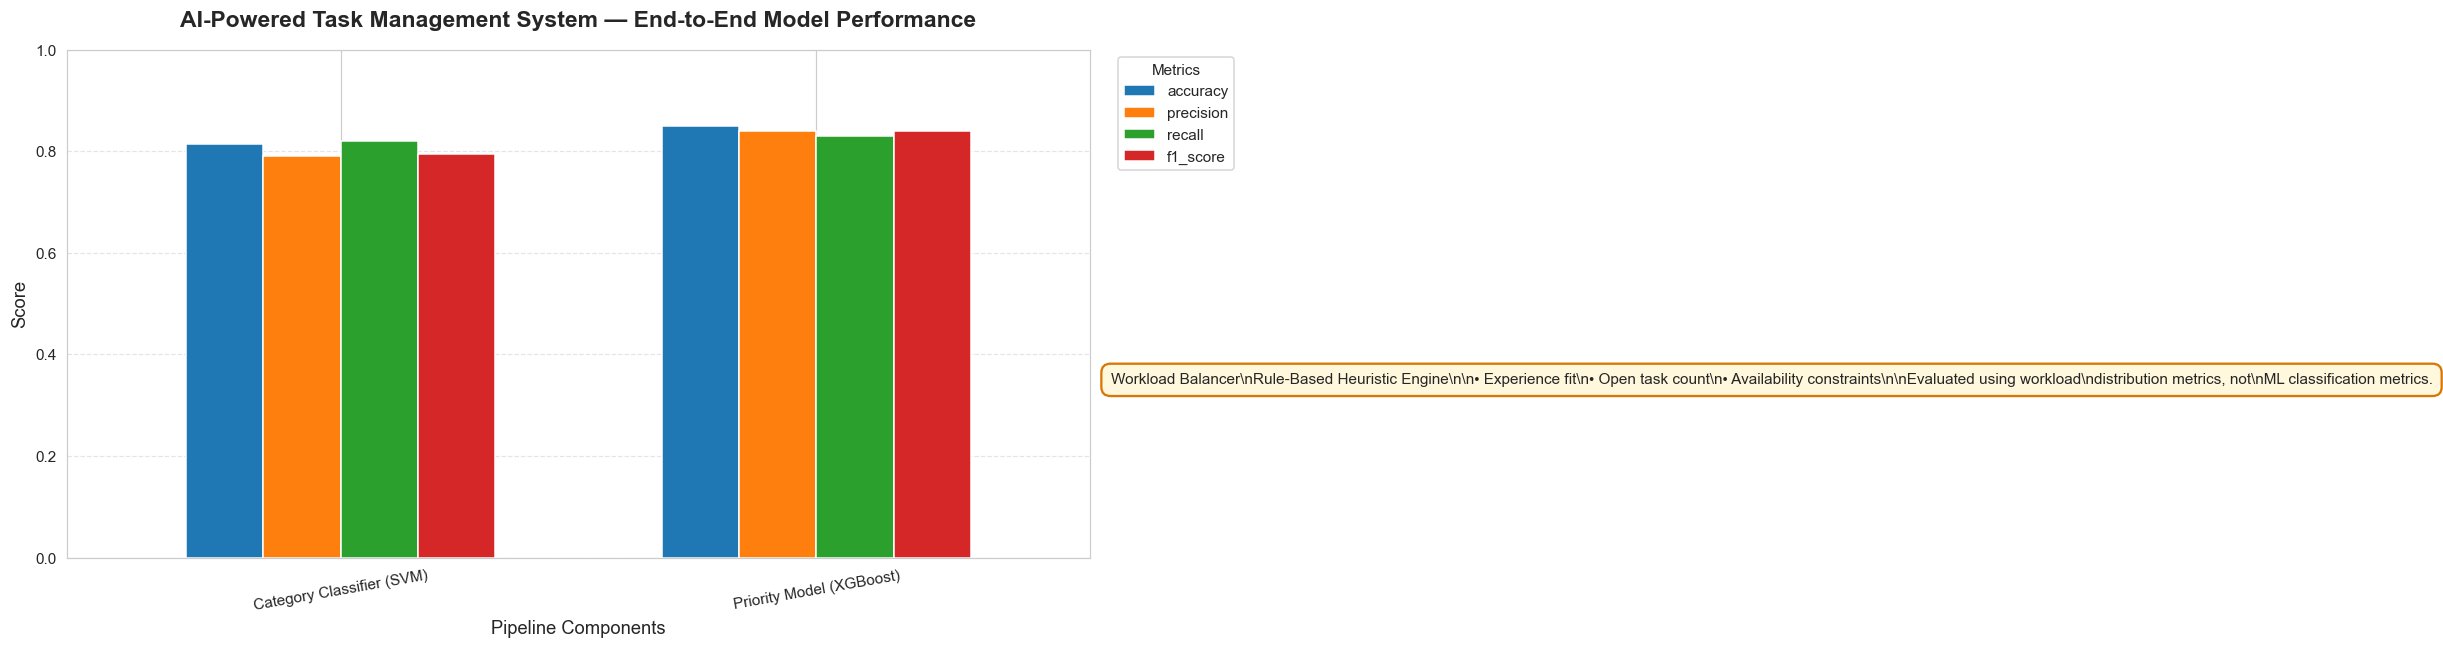

Chart saved successfully: reports/final_pipeline_summary.png


In [39]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Prepare data
# -----------------------------
ml_metrics = all_metrics.loc[
    ["Category Classifier (SVM)", "Priority Model (XGBoost)"]
].astype(float)

# Create reports folder automatically
os.makedirs("reports", exist_ok=True)

# Better plotting style
sns.set_style("whitegrid")

# -----------------------------
# Create figure
# -----------------------------
fig, ax = plt.subplots(figsize=(12, 6))

ml_metrics.plot(
    kind="bar",
    ax=ax,
    width=0.65
)

# -----------------------------
# Formatting
# -----------------------------
ax.set_title(
    "AI-Powered Task Management System — End-to-End Model Performance",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_ylabel("Score", fontsize=12)
ax.set_xlabel("Pipeline Components", fontsize=12)
ax.set_ylim(0, 1.0)

ax.legend(
    title="Metrics",
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=10, ha="center")
ax.grid(axis="y", linestyle="--", alpha=0.5)

# -----------------------------
# Workload balancer annotation
# -----------------------------
annotation_text = (
    "Workload Balancer\\n"
    "Rule-Based Heuristic Engine\\n\\n"
    "• Experience fit\\n"
    "• Open task count\\n"
    "• Availability constraints\\n\\n"
    "Evaluated using workload\\n"
    "distribution metrics, not\\n"
    "ML classification metrics."
)

ax.text(
    1.02, 0.35,
    annotation_text,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment="center",
    bbox=dict(
        boxstyle="round,pad=0.6",
        facecolor="#FFF8DC",
        edgecolor="#D97706",
        linewidth=1.5
    )
)

# -----------------------------
# Layout and save
# -----------------------------
plt.tight_layout()

output_path = "reports/final_pipeline_summary.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Chart saved successfully: {output_path}")

In [40]:
import os

# Create ROOT reports folder (one level above notebooks)
os.makedirs('../reports', exist_ok=True)

output_path = '../reports/final_pipeline_summary.png'

plt.tight_layout()
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

print(f'Chart saved successfully: {os.path.abspath(output_path)}')

<Figure size 704x528 with 0 Axes>

Chart saved successfully: c:\Users\Admin\Downloads\AI-Powered-Task-Management-System-00a92aff0f7adc1880793a9cd263675ce9dece95\reports\final_pipeline_summary.png


In [41]:
import os

model_path = '../models/final_priority_model.joblib'
print('Model exists:', os.path.exists(model_path))
print('Absolute path:', os.path.abspath(model_path))

Model exists: True
Absolute path: c:\Users\Admin\Downloads\AI-Powered-Task-Management-System-00a92aff0f7adc1880793a9cd263675ce9dece95\models\final_priority_model.joblib


In [42]:
import os

checks = {
    'Notebook': '11_Final_Performance_Summary.ipynb',
    'XGBoost Model': '../models/final_priority_model.joblib',
    'Preprocessor': '../models/final_priority_model_preprocessor.joblib',
    'Label Encoder': '../models/final_priority_model_label_encoder.joblib',
    'Final Chart': '../reports/final_pipeline_summary.png'
}

for name, path in checks.items():
    status = 'PASS' if os.path.exists(path) else 'FAIL'
    print(f'{name:15} : {status}')

Notebook        : FAIL
XGBoost Model   : PASS
Preprocessor    : PASS
Label Encoder   : PASS
Final Chart     : PASS


# Final deliverables completed:

• notebooks/11_Final_Performance_Summary.ipynb — consolidated evaluation notebook
• models/final_priority_model.joblib — final XGBoost priority classifier
• models/final_priority_model_preprocessor.joblib — preprocessing pipeline
• models/final_priority_model_label_encoder.joblib — label encoder
• reports/final_pipeline_summary.png — final pipeline comparison chart

The notebook includes Week 2 category classification results, Week 3 priority prediction results, and the workload balancing heuristic evaluation with the appropriate non-ML evaluation explanation.
